# Data Analysis Of Canteen Sales And Inventory

# 1. Load Data

In [1]:
import pandas as pd

In [2]:
sales = pd.read_csv("../data/raw/sales.csv")
inventory = pd.read_csv("../data/raw/inventory.csv")

# 2. Initial Exploration

In [3]:
sales.head()

,sale_id,date_of_sale,item_name,category,quantity_sold,unit_price,payment_mode,customer_type
0,1,08-09-2025,Coffee,Beverage,7,36.0,Card,Staff
1,2,25-10-2025,Sandwich,Snacks,7,Rs 12,UPI,Student
2,3,15-10-2025,Tea,Beverage,6,26â‚¹,UPI,Staff
3,4,02-10-2025,Chips,Snacks,3,36â‚¹,Card,Student
4,5,18-10-2025,Juice,Beverage,2,30.0,Cash,Student


In [4]:
inventory.head()

,inventory_id,date_of_entry,item_name,stock_in,stock_used,remaining_stock,unit_cost,supplier_name
0,1,30-10-2025,Tea,53,40,13,5â‚¹,FreshFoods Pvt Ltd
1,2,28-10-2025,Pasta,57,38,19,Rs 33,DailySupply Co.
2,3,16-08-2025,Chips,59,43,16,Rs 23,BeverageHub
3,4,06-10-2025,Juice,76,59,17,12,FreshFoods Pvt Ltd
4,5,23-10-2025,Juice,38,12,26,Rs 40,SuperSnacks Traders


In [5]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   inventory_id     90 non-null     int64 
 1   date_of_entry    90 non-null     object
 2   item_name        90 non-null     object
 3   stock_in         90 non-null     int64 
 4   stock_used       90 non-null     int64 
 5   remaining_stock  90 non-null     int64 
 6   unit_cost        90 non-null     object
 7   supplier_name    90 non-null     object
dtypes: int64(4), object(4)
memory usage: 5.8+ KB


In [6]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   sale_id        160 non-null    int64 
 1   date_of_sale   160 non-null    object
 2   item_name      160 non-null    object
 3   category       160 non-null    object
 4   quantity_sold  160 non-null    int64 
 5   unit_price     160 non-null    object
 6   payment_mode   160 non-null    object
 7   customer_type  160 non-null    object
dtypes: int64(2), object(6)
memory usage: 10.1+ KB


# 3. Cleaning Sales Dataframe

In [7]:
sales['date_of_sale'].head()

0    08-09-2025
1    25-10-2025
2    15-10-2025
3    02-10-2025
4    18-10-2025
Name: date_of_sale, dtype: object

In [8]:
# Cleaning Date as it is in multiple formats
sales['date_of_sale'] = pd.to_datetime(sales['date_of_sale'],dayfirst=True)

In [9]:
sales['date_of_sale']

0     2025-09-08
1     2025-10-25
2     2025-10-15
3     2025-10-02
4     2025-10-18
         ...    
155   2025-09-07
156   2025-09-21
157   2025-08-10
158   2025-09-10
159   2025-10-10
Name: date_of_sale, Length: 160, dtype: datetime64[ns]

In [10]:
# Extract Month and Day from date
sales['month'] = sales['date_of_sale'].dt.month
sales['day'] = sales['date_of_sale'].dt.day
sales['month_name'] = sales['date_of_sale'].dt.strftime('%B')
sales['weekday'] = sales['date_of_sale'].dt.day_name()

In [11]:
sales.head()

,sale_id,date_of_sale,item_name,category,quantity_sold,unit_price,payment_mode,customer_type,month,day,month_name,weekday
0,1,2025-09-08,Coffee,Beverage,7,36.0,Card,Staff,9,8,September,Monday
1,2,2025-10-25,Sandwich,Snacks,7,Rs 12,UPI,Student,10,25,October,Saturday
2,3,2025-10-15,Tea,Beverage,6,26â‚¹,UPI,Staff,10,15,October,Wednesday
3,4,2025-10-02,Chips,Snacks,3,36â‚¹,Card,Student,10,2,October,Thursday
4,5,2025-10-18,Juice,Beverage,2,30.0,Cash,Student,10,18,October,Saturday


In [12]:
sales['unit_price']

0       36.0
1      Rs 12
2      26â‚¹
3      36â‚¹
4       30.0
       ...  
155    Rs 67
156     71.0
157     60.0
158    Rs 16
159    46â‚¹
Name: unit_price, Length: 160, dtype: object

In [13]:
# Cleaning unit_price
# The unit_price column contains symbols. 
# Removing non-numeric characters using regex.
import re

def clean_price(x):
    if pd.isna(x):
        return None
    x = str(x)
    x = re.sub(r'[^0-9.]', '', x)  
    return pd.to_numeric(x)

sales['unit_price'] = sales['unit_price'].apply(clean_price)

In [14]:
sales.head()

,sale_id,date_of_sale,item_name,category,quantity_sold,unit_price,payment_mode,customer_type,month,day,month_name,weekday
0,1,2025-09-08,Coffee,Beverage,7,36.0,Card,Staff,9,8,September,Monday
1,2,2025-10-25,Sandwich,Snacks,7,12.0,UPI,Student,10,25,October,Saturday
2,3,2025-10-15,Tea,Beverage,6,26.0,UPI,Staff,10,15,October,Wednesday
3,4,2025-10-02,Chips,Snacks,3,36.0,Card,Student,10,2,October,Thursday
4,5,2025-10-18,Juice,Beverage,2,30.0,Cash,Student,10,18,October,Saturday


In [15]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 160 entries, 0 to 159
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   sale_id        160 non-null    int64         
 1   date_of_sale   160 non-null    datetime64[ns]
 2   item_name      160 non-null    object        
 3   category       160 non-null    object        
 4   quantity_sold  160 non-null    int64         
 5   unit_price     160 non-null    float64       
 6   payment_mode   160 non-null    object        
 7   customer_type  160 non-null    object        
 8   month          160 non-null    int32         
 9   day            160 non-null    int32         
 10  month_name     160 non-null    object        
 11  weekday        160 non-null    object        
dtypes: datetime64[ns](1), float64(1), int32(2), int64(2), object(6)
memory usage: 13.9+ KB


In [16]:
# Text values are standard
sales['item_name'].unique()

array(['Coffee', 'Sandwich', 'Tea', 'Chips', 'Juice', 'Cold Drink',
       'Burger', 'Momos', 'Pasta', 'Samosa'], dtype=object)

In [17]:
sales['category'].unique()

array(['Beverage', 'Snacks', 'Fast Food'], dtype=object)

In [18]:
# check for missing values
sales.isna().sum()

sale_id          0
date_of_sale     0
item_name        0
category         0
quantity_sold    0
unit_price       0
payment_mode     0
customer_type    0
month            0
day              0
month_name       0
weekday          0
dtype: int64

In [19]:
# check for duplicates
sales.duplicated().sum()

np.int64(0)

In [20]:
# check for outliers
sales['quantity_sold'].unique()

array([7, 6, 3, 2, 4, 5, 8, 1])

In [21]:
sales.head()

,sale_id,date_of_sale,item_name,category,quantity_sold,unit_price,payment_mode,customer_type,month,day,month_name,weekday
0,1,2025-09-08,Coffee,Beverage,7,36.0,Card,Staff,9,8,September,Monday
1,2,2025-10-25,Sandwich,Snacks,7,12.0,UPI,Student,10,25,October,Saturday
2,3,2025-10-15,Tea,Beverage,6,26.0,UPI,Staff,10,15,October,Wednesday
3,4,2025-10-02,Chips,Snacks,3,36.0,Card,Student,10,2,October,Thursday
4,5,2025-10-18,Juice,Beverage,2,30.0,Cash,Student,10,18,October,Saturday


In [22]:
# Total amount 
sales['total_amount'] = sales['quantity_sold']*sales['unit_price']
sales.head()

,sale_id,date_of_sale,item_name,category,quantity_sold,unit_price,payment_mode,customer_type,month,day,month_name,weekday,total_amount
0,1,2025-09-08,Coffee,Beverage,7,36.0,Card,Staff,9,8,September,Monday,252.0
1,2,2025-10-25,Sandwich,Snacks,7,12.0,UPI,Student,10,25,October,Saturday,84.0
2,3,2025-10-15,Tea,Beverage,6,26.0,UPI,Staff,10,15,October,Wednesday,156.0
3,4,2025-10-02,Chips,Snacks,3,36.0,Card,Student,10,2,October,Thursday,108.0
4,5,2025-10-18,Juice,Beverage,2,30.0,Cash,Student,10,18,October,Saturday,60.0


# 4. Cleaning Inventory Dataframe

In [23]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   inventory_id     90 non-null     int64 
 1   date_of_entry    90 non-null     object
 2   item_name        90 non-null     object
 3   stock_in         90 non-null     int64 
 4   stock_used       90 non-null     int64 
 5   remaining_stock  90 non-null     int64 
 6   unit_cost        90 non-null     object
 7   supplier_name    90 non-null     object
dtypes: int64(4), object(4)
memory usage: 5.8+ KB


In [24]:
# change date from object to datetime format
inventory['date_of_entry'] = pd.to_datetime(inventory['date_of_entry'], dayfirst=True)

In [25]:
inventory['date_of_entry']

0    2025-10-30
1    2025-10-28
2    2025-08-16
3    2025-10-06
4    2025-10-23
        ...    
85   2025-10-07
86   2025-10-22
87   2025-10-11
88   2025-09-27
89   2025-08-04
Name: date_of_entry, Length: 90, dtype: datetime64[ns]

In [26]:
#Extract Month and Day from date
inventory['month'] = inventory['date_of_entry'].dt.month
inventory['day'] = inventory['date_of_entry'].dt.day
inventory['month_name'] = inventory['date_of_entry'].dt.strftime('%B')

In [27]:
inventory.head()

,inventory_id,date_of_entry,item_name,stock_in,stock_used,remaining_stock,unit_cost,supplier_name,month,day,month_name
0,1,2025-10-30,Tea,53,40,13,5â‚¹,FreshFoods Pvt Ltd,10,30,October
1,2,2025-10-28,Pasta,57,38,19,Rs 33,DailySupply Co.,10,28,October
2,3,2025-08-16,Chips,59,43,16,Rs 23,BeverageHub,8,16,August
3,4,2025-10-06,Juice,76,59,17,12,FreshFoods Pvt Ltd,10,6,October
4,5,2025-10-23,Juice,38,12,26,Rs 40,SuperSnacks Traders,10,23,October


In [28]:
inventory['item_name'].unique()

array(['Tea', 'Pasta', 'Chips', 'Juice', 'Burger', 'Cold Drink', 'Momos',
       'Coffee', 'Samosa', 'Sandwich'], dtype=object)

In [29]:
inventory['supplier_name'].unique()

array(['FreshFoods Pvt Ltd', 'DailySupply Co.', 'BeverageHub',
       'SuperSnacks Traders'], dtype=object)

In [30]:
#clean unit_cost column by applying clean_price() function defined before
inventory['unit_cost'] = inventory['unit_cost'].apply(clean_price)

In [31]:
inventory.head()

,inventory_id,date_of_entry,item_name,stock_in,stock_used,remaining_stock,unit_cost,supplier_name,month,day,month_name
0,1,2025-10-30,Tea,53,40,13,5,FreshFoods Pvt Ltd,10,30,October
1,2,2025-10-28,Pasta,57,38,19,33,DailySupply Co.,10,28,October
2,3,2025-08-16,Chips,59,43,16,23,BeverageHub,8,16,August
3,4,2025-10-06,Juice,76,59,17,12,FreshFoods Pvt Ltd,10,6,October
4,5,2025-10-23,Juice,38,12,26,40,SuperSnacks Traders,10,23,October


In [32]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   inventory_id     90 non-null     int64         
 1   date_of_entry    90 non-null     datetime64[ns]
 2   item_name        90 non-null     object        
 3   stock_in         90 non-null     int64         
 4   stock_used       90 non-null     int64         
 5   remaining_stock  90 non-null     int64         
 6   unit_cost        90 non-null     int64         
 7   supplier_name    90 non-null     object        
 8   month            90 non-null     int32         
 9   day              90 non-null     int32         
 10  month_name       90 non-null     object        
dtypes: datetime64[ns](1), int32(2), int64(5), object(3)
memory usage: 7.2+ KB


In [33]:
#check for missing values
inventory.isna().sum()

inventory_id       0
date_of_entry      0
item_name          0
stock_in           0
stock_used         0
remaining_stock    0
unit_cost          0
supplier_name      0
month              0
day                0
month_name         0
dtype: int64

In [34]:
#check for duplicates
inventory.duplicated().sum()

np.int64(0)

In [35]:
# Exporting cleaned data
sales.to_csv("../data/cleaned/sales_cleaned.csv", index=False)
inventory.to_csv("../data/cleaned/inventory_cleaned.csv", index=False)

# 5. Sales Analysis

In [36]:
sales.head()

,sale_id,date_of_sale,item_name,category,quantity_sold,unit_price,payment_mode,customer_type,month,day,month_name,weekday,total_amount
0,1,2025-09-08,Coffee,Beverage,7,36.0,Card,Staff,9,8,September,Monday,252.0
1,2,2025-10-25,Sandwich,Snacks,7,12.0,UPI,Student,10,25,October,Saturday,84.0
2,3,2025-10-15,Tea,Beverage,6,26.0,UPI,Staff,10,15,October,Wednesday,156.0
3,4,2025-10-02,Chips,Snacks,3,36.0,Card,Student,10,2,October,Thursday,108.0
4,5,2025-10-18,Juice,Beverage,2,30.0,Cash,Student,10,18,October,Saturday,60.0


In [37]:
# Overview of sales in 3 months
total_sales = sales['total_amount'].sum()
total_qty = sales['quantity_sold'].sum()
num_transactions = sales['sale_id'].nunique()
aov = total_sales / num_transactions

print("Three months Overview:\n")
print(f"Total Sales Revenue: {total_sales}")
print(f"Total Quantity Sold: {total_qty}")
print(f"Number of Transactions: {num_transactions}")
print(f"Average Order Value (AOV): {aov}")

Three months Overview:

Total Sales Revenue: 30960.0
Total Quantity Sold: 707
Number of Transactions: 160
Average Order Value (AOV): 193.5


### Time-series analysis

In [38]:
sales.head()

,sale_id,date_of_sale,item_name,category,quantity_sold,unit_price,payment_mode,customer_type,month,day,month_name,weekday,total_amount
0,1,2025-09-08,Coffee,Beverage,7,36.0,Card,Staff,9,8,September,Monday,252.0
1,2,2025-10-25,Sandwich,Snacks,7,12.0,UPI,Student,10,25,October,Saturday,84.0
2,3,2025-10-15,Tea,Beverage,6,26.0,UPI,Staff,10,15,October,Wednesday,156.0
3,4,2025-10-02,Chips,Snacks,3,36.0,Card,Student,10,2,October,Thursday,108.0
4,5,2025-10-18,Juice,Beverage,2,30.0,Cash,Student,10,18,October,Saturday,60.0


In [39]:
# Calculate daily revenue
daily_sales = sales.groupby('date_of_sale')['total_amount'].sum().reset_index()
daily_sales

,date_of_sale,total_amount
0,2025-08-02,124.0
1,2025-08-03,482.0
2,2025-08-07,673.0
3,2025-08-08,288.0
4,2025-08-10,1430.0
...,...,...
70,2025-10-26,196.0
71,2025-10-27,51.0
72,2025-10-28,340.0
73,2025-10-29,216.0


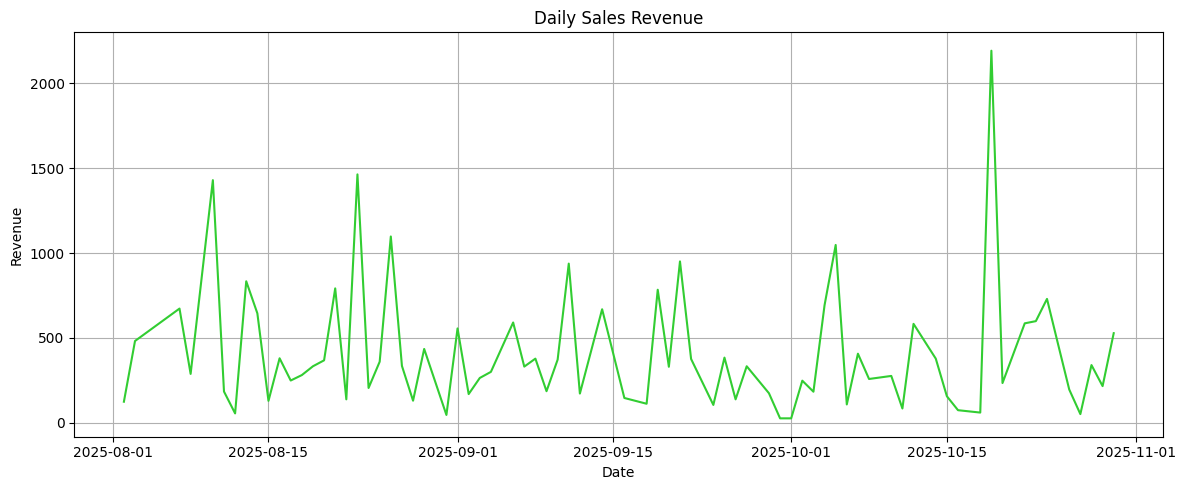

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(daily_sales['date_of_sale'], daily_sales['total_amount'], color="limegreen")
plt.title('Daily Sales Revenue')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()

In [41]:
month_order = ["August", "September", "October"]
sales["month_name"] = pd.Categorical(
    sales["month_name"],
    categories=month_order,
    ordered=True
)

In [42]:
# Sales by Month
monthly_sales = sales.groupby('month_name', observed=True)['total_amount'].sum().reset_index()
monthly_sales

,month_name,total_amount
0,August,11458.0
1,September,8785.0
2,October,10717.0


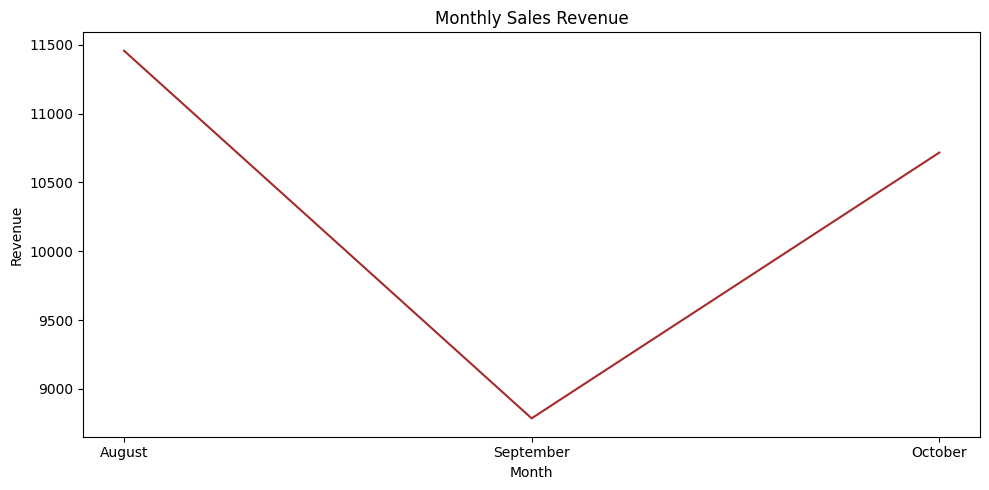

In [43]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['month_name'], monthly_sales['total_amount'], color="brown")
plt.title('Monthly Sales Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
# plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
# Sales by Weekday
weekday_sales = sales.groupby('weekday')['total_amount'].sum().reset_index()
weekday_sales

,weekday,total_amount
0,Friday,3273.0
1,Monday,2702.0
2,Saturday,4521.0
3,Sunday,8383.0
4,Thursday,5423.0
5,Tuesday,3138.0
6,Wednesday,3520.0


In [45]:
#sort by actual order
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_sales['weekday'] = pd.Categorical(weekday_sales['weekday'], categories=order, ordered=True)
weekday_sales = weekday_sales.sort_values('weekday')
weekday_sales

,weekday,total_amount
1,Monday,2702.0
5,Tuesday,3138.0
6,Wednesday,3520.0
4,Thursday,5423.0
0,Friday,3273.0
2,Saturday,4521.0
3,Sunday,8383.0


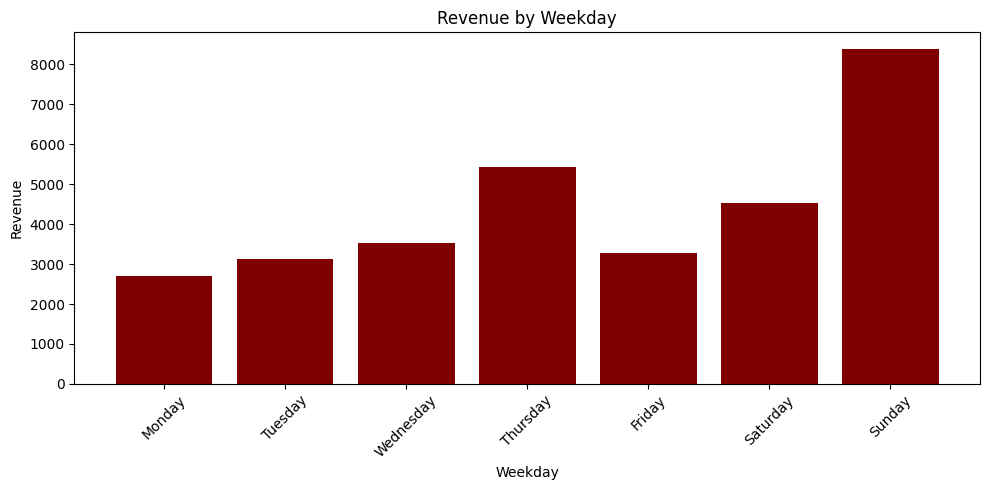

In [46]:
plt.figure(figsize=(10,5))
plt.bar(weekday_sales['weekday'], weekday_sales['total_amount'], color="maroon")
plt.title('Revenue by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Product analysis

In [47]:
sales.head()

,sale_id,date_of_sale,item_name,category,quantity_sold,unit_price,payment_mode,customer_type,month,day,month_name,weekday,total_amount
0,1,2025-09-08,Coffee,Beverage,7,36.0,Card,Staff,9,8,September,Monday,252.0
1,2,2025-10-25,Sandwich,Snacks,7,12.0,UPI,Student,10,25,October,Saturday,84.0
2,3,2025-10-15,Tea,Beverage,6,26.0,UPI,Staff,10,15,October,Wednesday,156.0
3,4,2025-10-02,Chips,Snacks,3,36.0,Card,Student,10,2,October,Thursday,108.0
4,5,2025-10-18,Juice,Beverage,2,30.0,Cash,Student,10,18,October,Saturday,60.0


In [48]:
# Total Quantity Sold per Item
qty_per_item = (sales.groupby('item_name')['quantity_sold'].sum().reset_index().sort_values('quantity_sold', ascending=False))
qty_per_item

,item_name,quantity_sold
3,Cold Drink,105
4,Juice,93
9,Tea,77
7,Samosa,76
0,Burger,74
8,Sandwich,70
2,Coffee,70
6,Pasta,60
1,Chips,51
5,Momos,31


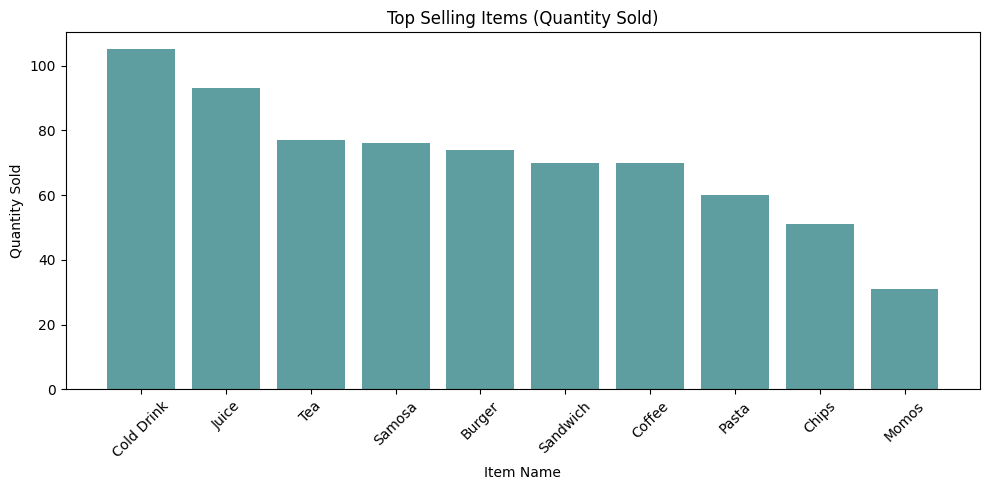

In [49]:
# Top Selling Items (Quantity)
plt.figure(figsize=(10,5))
plt.bar(qty_per_item['item_name'], qty_per_item['quantity_sold'], color="#5F9EA0")
plt.title('Top Selling Items (Quantity Sold)')
plt.xlabel('Item Name')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Revenue Analysis

In [50]:
# Total Revenue per Item
rev_per_item = (sales.groupby('item_name')['total_amount'].sum().reset_index().sort_values('total_amount', ascending=False))
rev_per_item

,item_name,total_amount
3,Cold Drink,4362.0
4,Juice,4357.0
9,Tea,3882.0
7,Samosa,3452.0
0,Burger,3004.0
6,Pasta,2933.0
2,Coffee,2838.0
8,Sandwich,2656.0
1,Chips,1970.0
5,Momos,1506.0


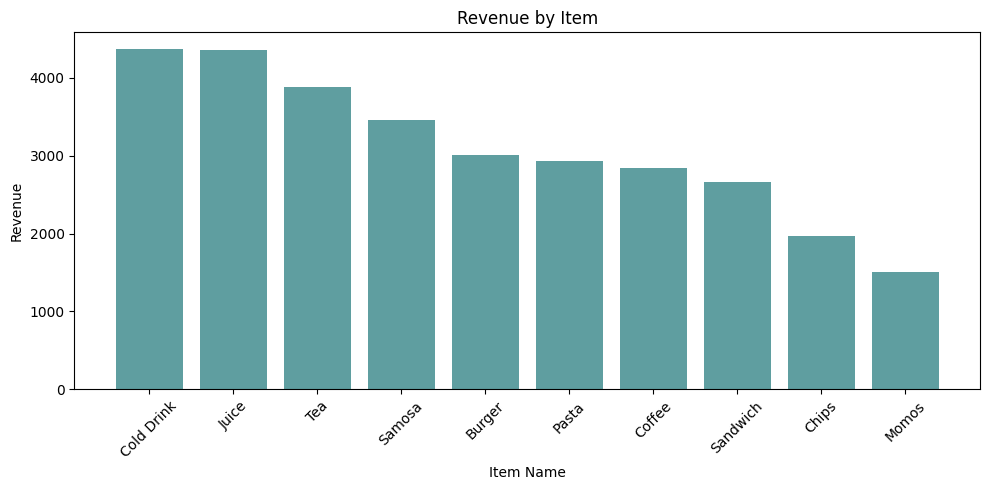

In [51]:
plt.figure(figsize=(10,5))
plt.bar(rev_per_item['item_name'], rev_per_item['total_amount'], color="#5F9EA0")
plt.title('Revenue by Item')
plt.xlabel('Item Name')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Category-Level Performance

In [52]:
# Quantity Sold by Category
cat_qty = (sales.groupby('category')['quantity_sold'].sum().reset_index().sort_values('quantity_sold', ascending=False))
cat_qty

,category,quantity_sold
0,Beverage,345
2,Snacks,197
1,Fast Food,165


In [53]:
# Revenue by Category
cat_rev = (sales.groupby('category')['total_amount'].sum().reset_index().sort_values('total_amount', ascending=False))
cat_rev

,category,total_amount
0,Beverage,15439.0
2,Snacks,8078.0
1,Fast Food,7443.0


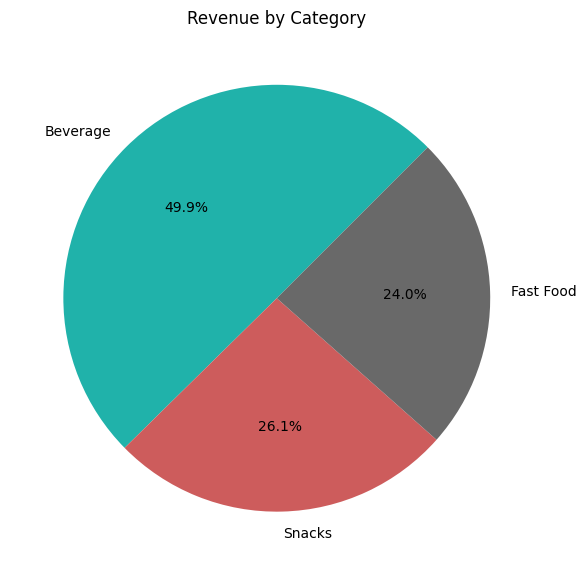

In [54]:
colors = ['#20B2AA', '#CD5C5C', '#696969'] 
plt.figure(figsize=(6,6))
plt.pie(
    cat_rev['total_amount'],
    labels=cat_rev['category'],
    autopct='%1.1f%%',
    startangle=45,
    colors=colors
)
plt.title("Revenue by Category")
plt.tight_layout()
plt.show()

### Best & Worst Products

In [55]:
# Top 5 Items by Quantity which sold most
qty_per_item.head()

,item_name,quantity_sold
3,Cold Drink,105
4,Juice,93
9,Tea,77
7,Samosa,76
0,Burger,74


In [56]:
# Bottom 5 Items by Quantity which sold least
qty_per_item.tail()

,item_name,quantity_sold
8,Sandwich,70
2,Coffee,70
6,Pasta,60
1,Chips,51
5,Momos,31


In [57]:
# Top 5 Items by Revenue
rev_per_item.head()

,item_name,total_amount
3,Cold Drink,4362.0
4,Juice,4357.0
9,Tea,3882.0
7,Samosa,3452.0
0,Burger,3004.0


In [58]:
# Bottom 5 Items by Revenue
rev_per_item.tail()

,item_name,total_amount
6,Pasta,2933.0
2,Coffee,2838.0
8,Sandwich,2656.0
1,Chips,1970.0
5,Momos,1506.0


### Price Analysis

In [59]:
avg_price = (sales.groupby('item_name')['unit_price'].mean().reset_index().sort_values('unit_price', ascending=False))
avg_price

,item_name,unit_price
9,Tea,52.055556
5,Momos,48.875000
4,Juice,48.315789
6,Pasta,47.285714
7,Samosa,47.055556
8,Sandwich,46.333333
3,Cold Drink,44.200000
2,Coffee,43.800000
0,Burger,41.526316
1,Chips,38.500000


### Customer Analysis

In [60]:
# Sales Count by Customer Type
sales['customer_type'].value_counts()

customer_type
Visitor    61
Student    56
Staff      43
Name: count, dtype: int64

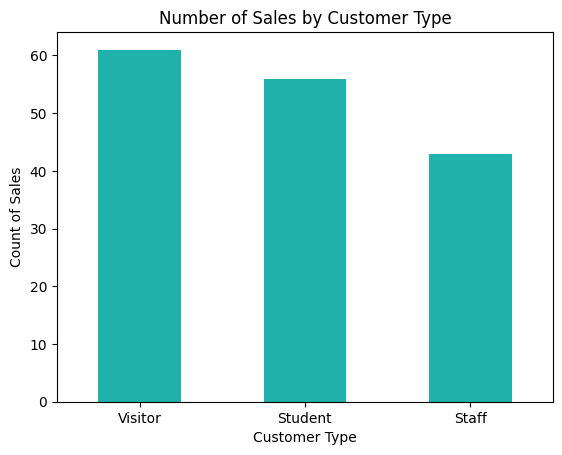

In [61]:
sales['customer_type'].value_counts().plot(kind='bar', color="#20B2AA")
plt.title("Number of Sales by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Count of Sales")
plt.xticks(rotation=0)
plt.show()

In [62]:
# Total Revenue by Customer Type
customer_revenue = sales.groupby('customer_type')['total_amount'].sum().sort_values(ascending=False)
customer_revenue

customer_type
Visitor    12177.0
Student    10149.0
Staff       8634.0
Name: total_amount, dtype: float64

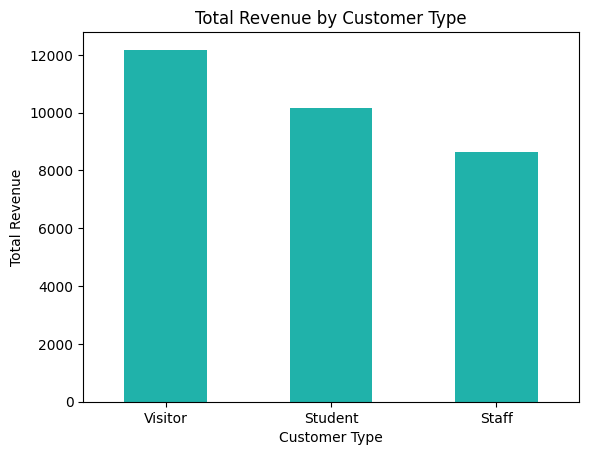

In [63]:
customer_revenue.plot(kind='bar',  color="#20B2AA")
plt.title("Total Revenue by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.show()

In [64]:
# Average Order Value (AOV) by Customer Type
aov = sales.groupby('customer_type')['total_amount'].mean().round(2)
aov

customer_type
Staff      200.79
Student    181.23
Visitor    199.62
Name: total_amount, dtype: float64

In [65]:
# Quantity Purchased per Order (Which customer buys more?)
qty_by_customer = sales.groupby('customer_type')['quantity_sold'].mean().round(2)
qty_by_customer

customer_type
Staff      4.51
Student    4.66
Visitor    4.13
Name: quantity_sold, dtype: float64

### Payment Mode Analysis

In [66]:
# Number of Sales by Payment Mode
sales['payment_mode'].value_counts()

payment_mode
Cash    60
UPI     54
Card    46
Name: count, dtype: int64

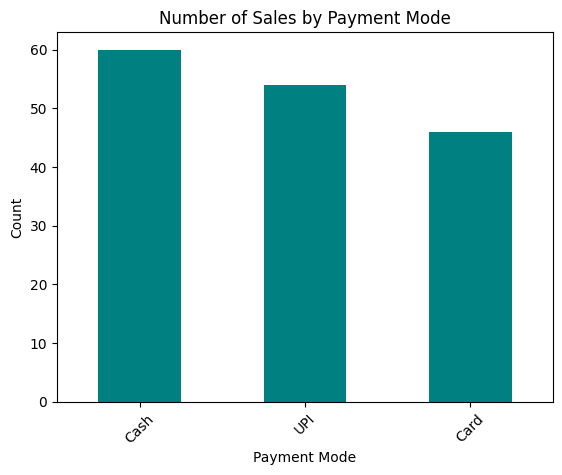

In [67]:
sales['payment_mode'].value_counts().plot(kind='bar', color='#008080')
plt.title("Number of Sales by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [68]:
# Total Revenue by Payment Mode
payment_revenue = sales.groupby('payment_mode')['total_amount'].sum().sort_values(ascending=False)
payment_revenue

payment_mode
UPI     11451.0
Cash    10904.0
Card     8605.0
Name: total_amount, dtype: float64

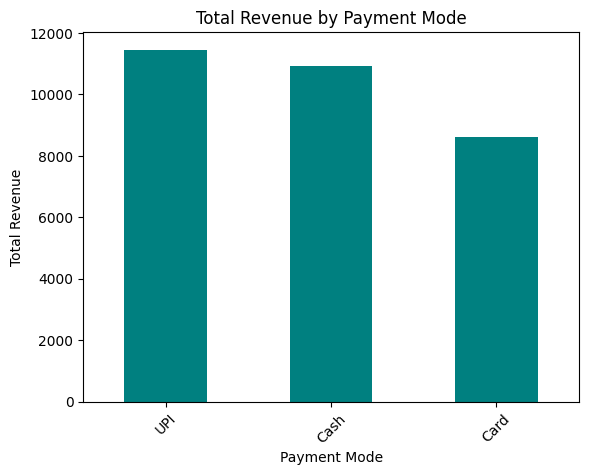

In [69]:
payment_revenue.plot(kind='bar', color='#008080')
plt.title("Total Revenue by Payment Mode")
plt.xlabel("Payment Mode")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

In [70]:
# Average Order Value by Payment Mode
payment_aov = sales.groupby('payment_mode')['total_amount'].mean().round(2)
payment_aov

payment_mode
Card    187.07
Cash    181.73
UPI     212.06
Name: total_amount, dtype: float64

In [71]:
# Contribution % of each payment mode
contribution = (payment_revenue / payment_revenue.sum() * 100).round(2)
contribution

payment_mode
UPI     36.99
Cash    35.22
Card    27.79
Name: total_amount, dtype: float64

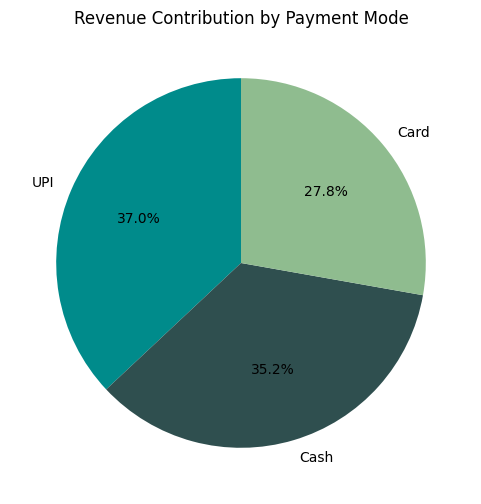

In [72]:
colors = ['#008B8B', '#2F4F4F', '#8FBC8F']

plt.figure(figsize=(6,6))
plt.pie(
    contribution,
    labels=contribution.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors
)
plt.title("Revenue Contribution by Payment Mode")
plt.show()

### Quick Insights:

# 6. Inventory Analysis

In [73]:
inventory.head()

,inventory_id,date_of_entry,item_name,stock_in,stock_used,remaining_stock,unit_cost,supplier_name,month,day,month_name
0,1,2025-10-30,Tea,53,40,13,5,FreshFoods Pvt Ltd,10,30,October
1,2,2025-10-28,Pasta,57,38,19,33,DailySupply Co.,10,28,October
2,3,2025-08-16,Chips,59,43,16,23,BeverageHub,8,16,August
3,4,2025-10-06,Juice,76,59,17,12,FreshFoods Pvt Ltd,10,6,October
4,5,2025-10-23,Juice,38,12,26,40,SuperSnacks Traders,10,23,October


In [74]:
inventory.describe()[['stock_in', 'stock_used', 'remaining_stock', 'unit_cost']]

,stock_in,stock_used,remaining_stock,unit_cost
count,90.000000,90.000000,90.000000,90.000000
mean,59.655556,31.700000,27.955556,23.277778
min,20.000000,5.000000,1.000000,5.000000
25%,38.250000,15.000000,10.250000,17.000000
50%,58.500000,24.500000,18.000000,24.000000
75%,82.500000,43.000000,40.750000,32.000000
max,100.000000,97.000000,82.000000,40.000000
std,24.634479,21.020295,22.637302,10.171593


In [75]:
remaining = inventory.groupby('item_name')['remaining_stock'].sum().sort_values(ascending=False)
remaining

item_name
Samosa        444
Juice         404
Chips         300
Burger        291
Sandwich      253
Cold Drink    252
Tea           182
Coffee        161
Pasta         116
Momos         113
Name: remaining_stock, dtype: int64

In [76]:
# Reorder Level = 20% of Stock In
inventory['reorder_level'] = (inventory['stock_in'] * 0.20).round()

# Check items below reorder level
reorder_alert = inventory[inventory['remaining_stock'] <= inventory['reorder_level']]
reorder_alert[['item_name', 'remaining_stock', 'reorder_level']]

,item_name,remaining_stock,reorder_level
6,Cold Drink,11,13.0
8,Burger,2,15.0
12,Burger,4,5.0
14,Chips,8,17.0
16,Sandwich,9,9.0
17,Pasta,9,9.0
18,Samosa,5,19.0
21,Burger,7,11.0
25,Sandwich,10,10.0
33,Pasta,3,4.0


In [77]:
reorder_alert.groupby('item_name')['remaining_stock'].sum()

item_name
Burger        13
Chips         15
Coffee        27
Cold Drink    11
Juice         23
Momos         17
Pasta         12
Samosa        17
Sandwich      24
Name: remaining_stock, dtype: int64

In [78]:
# Fast-moving items: high stock_used
# Slow-moving items: low stock_used
usage = inventory.groupby('item_name')['stock_used'].sum().sort_values(ascending=False)
usage

item_name
Juice         544
Samosa        494
Chips         312
Coffee        307
Sandwich      267
Burger        209
Cold Drink    206
Pasta         203
Momos         190
Tea           121
Name: stock_used, dtype: int64

In [79]:
inventory['stock_value'] = inventory['remaining_stock'] * inventory['unit_cost']

stock_value = inventory.groupby('item_name')['stock_value'].sum().sort_values(ascending=False)
stock_value

item_name
Samosa        12170
Juice         10950
Burger         7460
Sandwich       5610
Chips          5011
Cold Drink     4681
Coffee         4609
Tea            3500
Momos          3352
Pasta          3092
Name: stock_value, dtype: int64

In [80]:
inventory.head()

,inventory_id,date_of_entry,item_name,stock_in,stock_used,remaining_stock,unit_cost,supplier_name,month,day,month_name,reorder_level,stock_value
0,1,2025-10-30,Tea,53,40,13,5,FreshFoods Pvt Ltd,10,30,October,11.0,65
1,2,2025-10-28,Pasta,57,38,19,33,DailySupply Co.,10,28,October,11.0,627
2,3,2025-08-16,Chips,59,43,16,23,BeverageHub,8,16,August,12.0,368
3,4,2025-10-06,Juice,76,59,17,12,FreshFoods Pvt Ltd,10,6,October,15.0,204
4,5,2025-10-23,Juice,38,12,26,40,SuperSnacks Traders,10,23,October,8.0,1040


In [81]:
supplier_summary = inventory.groupby('supplier_name')['stock_in'].sum().sort_values(ascending=False)
supplier_summary

supplier_name
DailySupply Co.        1500
BeverageHub            1337
FreshFoods Pvt Ltd     1297
SuperSnacks Traders    1235
Name: stock_in, dtype: int64

In [82]:
monthly_stock = inventory.groupby('month_name')['stock_in'].sum().sort_values()
monthly_stock

month_name
September    1193
August       1978
October      2198
Name: stock_in, dtype: int64

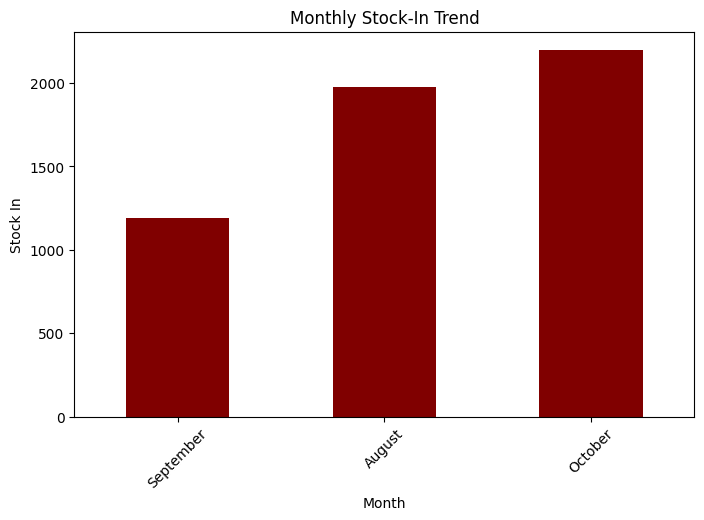

In [83]:
monthly_stock.plot(kind='bar', figsize=(8,5), color='maroon')
plt.title('Monthly Stock-In Trend')
plt.xlabel('Month')
plt.ylabel('Stock In')
plt.xticks(rotation=45)
plt.show()

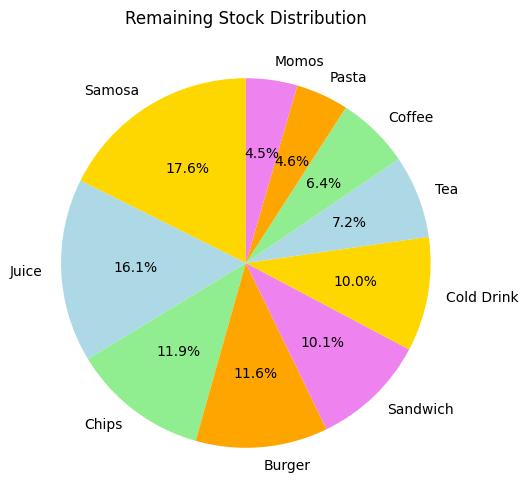

In [84]:
remaining.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    figsize=(6,6),
    colors=['gold', 'lightblue', 'lightgreen', 'orange', 'violet']
)
plt.ylabel('')
plt.title("Remaining Stock Distribution")
plt.show()

In [85]:
# demo

<Axes: ylabel='Frequency'>

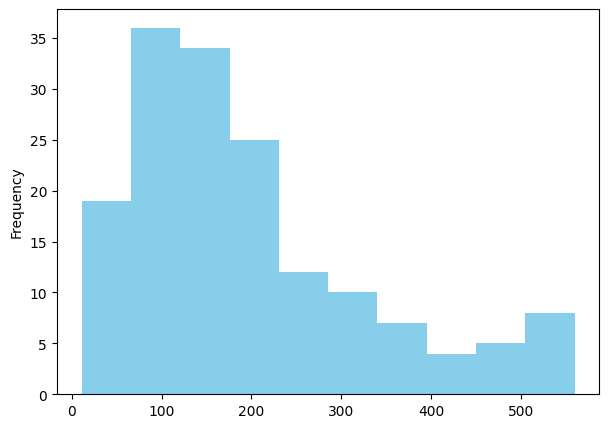

In [86]:
sales['total_amount'].plot(kind='hist', bins=10, figsize=(7,5), color="skyblue")

<Axes: ylabel='Frequency'>

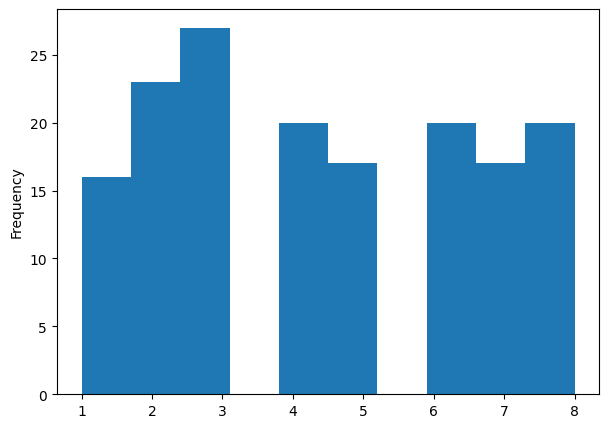

In [87]:
sales['quantity_sold'].plot(kind='hist', bins=10, figsize=(7,5))

<Axes: ylabel='Frequency'>

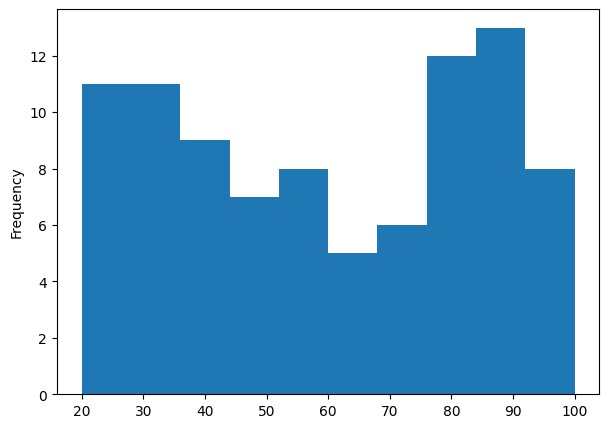

In [88]:
inventory['stock_in'].plot(kind='hist', bins=10, figsize=(7,5))

<Axes: ylabel='Frequency'>

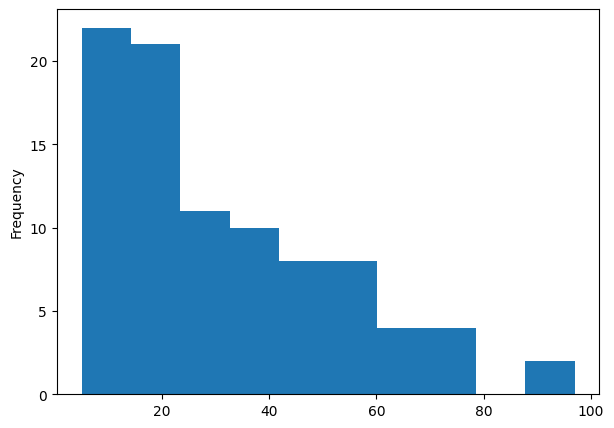

In [89]:
inventory['stock_used'].plot(kind='hist', bins=10, figsize=(7,5))

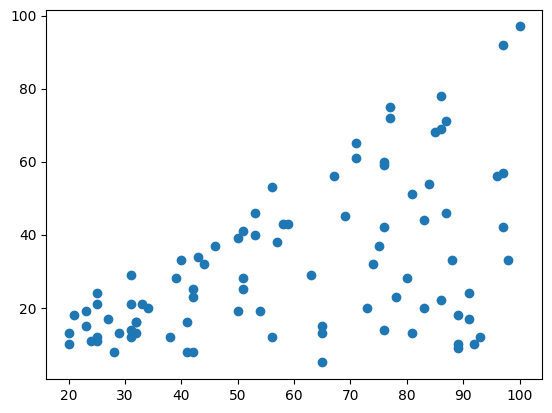

In [90]:
plt.scatter(inventory['stock_in'], inventory['stock_used'])

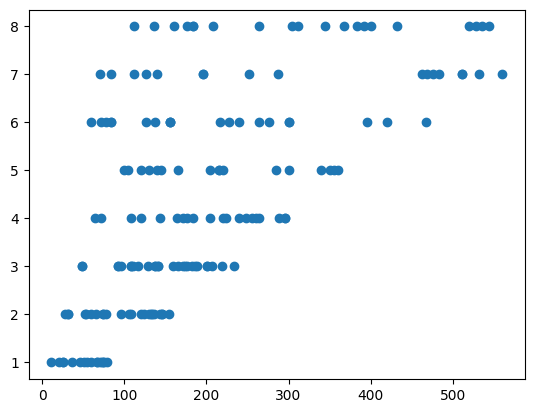

In [91]:
plt.scatter(sales['total_amount'], sales['quantity_sold'])

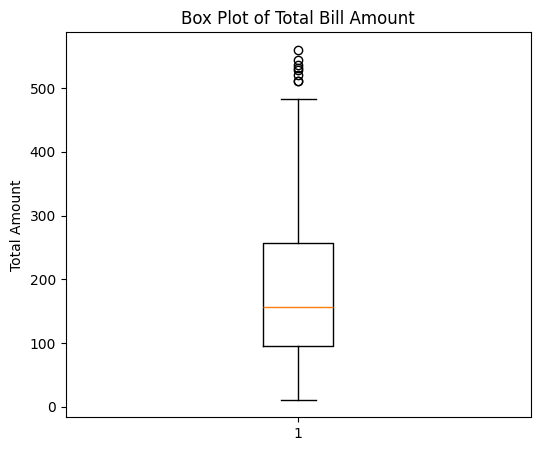

In [92]:
plt.figure(figsize=(6,5))
plt.boxplot(sales['total_amount'], vert=True)
plt.title("Box Plot of Total Bill Amount")
plt.ylabel("Total Amount")
plt.show()

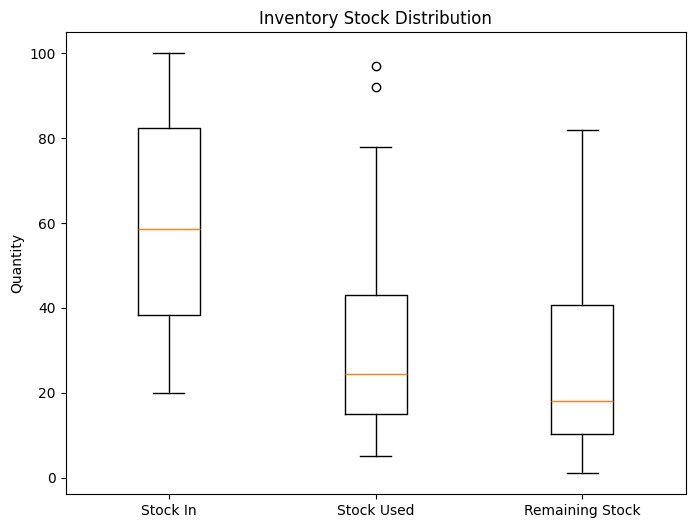

In [93]:
plt.figure(figsize=(8,6))

plt.boxplot(
    [inventory['stock_in'], inventory['stock_used'], inventory['remaining_stock']],
    tick_labels=['Stock In', 'Stock Used', 'Remaining Stock']
)

plt.title("Inventory Stock Distribution")
plt.ylabel("Quantity")
plt.show()

In [94]:
inventory.describe()

,inventory_id,date_of_entry,stock_in,stock_used,remaining_stock,unit_cost,month,day,reorder_level,stock_value
count,90.000000,90,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,45.500000,2025-09-15 07:28:00,59.655556,31.700000,27.955556,23.277778,9.033333,14.677778,11.900000,671.500000
min,1.000000,2025-08-01 00:00:00,20.000000,5.000000,1.000000,5.000000,8.000000,1.000000,4.000000,10.000000
25%,23.250000,2025-08-16 06:00:00,38.250000,15.000000,10.250000,17.000000,8.000000,6.000000,8.000000,201.000000
50%,45.500000,2025-09-23 12:00:00,58.500000,24.500000,18.000000,24.000000,9.000000,13.000000,12.000000,393.000000
75%,67.750000,2025-10-08 00:00:00,82.500000,43.000000,40.750000,32.000000,10.000000,23.000000,16.750000,976.500000
max,90.000000,2025-10-30 00:00:00,100.000000,97.000000,82.000000,40.000000,10.000000,31.000000,20.000000,3159.000000
std,26.124701,NaN,24.634479,21.020295,22.637302,10.171593,0.879862,9.448652,4.915122,693.824092


In [104]:
used = inventory['stock_used'].unique()
used.sort()
used

array([ 5,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23,
       24, 25, 28, 29, 32, 33, 34, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46,
       51, 53, 54, 56, 57, 59, 60, 61, 65, 68, 69, 71, 72, 75, 78, 92, 97])

In [122]:
inventory[(inventory['stock_used'] == 92) | (inventory['stock_used'] == 97)]

,inventory_id,date_of_entry,item_name,stock_in,stock_used,remaining_stock,unit_cost,supplier_name,month,day,month_name,reorder_level,stock_value
18,19,2025-08-09,Samosa,97,92,5,40,DailySupply Co.,8,9,August,19.0,200
80,81,2025-08-27,Juice,100,97,3,26,DailySupply Co.,8,27,August,20.0,78
